In [44]:
# Imports
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (roc_auc_score,
    accuracy_score,
    brier_score_loss)

import matplotlib.pyplot as plt
from xgboost import XGBClassifier
from tqdm import tqdm   

In [2]:
# Define temporal train/test split (w/o leakage)

def temporal_train_test_split(
    df: pd.DataFrame,
    time_col: int,
    class_col: str,
    train_frac: float = 0.8):
    
    # Sort df by time_col, do a 80/20 temporal split.
    # Returns: X_train, y_train, X_test, y_test
    
    # Sort by time ascending
    df_sorted = df.sort_values(by=time_col).reset_index(drop=True)

    # Compute split index
    split_idx = int(len(df_sorted) * train_frac)

    # Split
    train_df = df_sorted.iloc[:split_idx].copy()
    test_df  = df_sorted.iloc[split_idx:].copy()

    # Separate features and target
    X_train = train_df.drop(columns=[class_col])
    y_train = train_df[class_col].copy()

    X_test  = test_df.drop(columns=[class_col])
    y_test  = test_df[class_col].copy()

    return X_train, y_train, X_test, y_test, df_sorted


In [6]:
# Load dataset 

df = pd.read_csv("D:/Final Year/App Domains/Project/datasets/creditcard.csv")

# Set time col and then the target col 
time_col   = "Time"  
target_col = "Class" 

# Quick validation
print(df[[time_col, target_col]].head())


   Time  Class
0   0.0      0
1   0.0      0
2   1.0      0
3   1.0      0
4   2.0      0


In [34]:
# Temporal split and model training for dataset 

# Drop rows with missing time or target if necessary
df_clean = df.dropna(subset=[time_col, target_col]).copy()

# Temporal split
X_train, y_train, X_test, y_test, df_sorted = temporal_train_test_split(
    df_clean,
    time_col,
    target_col,
    train_frac=0.8
)

# Select feature columns (exclude time and target)
feature_cols = [c for c in X_train.columns if c != [time_col, target_col]]

X_train_feat = X_train[feature_cols]
X_test_feat  = X_test[feature_cols]

# Define pipeline ******* DIFFERENT PIPELINES FOR IMPROVEMENTS ? 
pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(max_iter=1000))
])

# Fit model
pipeline.fit(X_train_feat, y_train)

# Quick baseline performance on test set
y_test_pre_p = pipeline.predict_proba(X_test_feat)[:, 1]
y_test_pre = (y_test_pre_p >= 0.5).astype(int)

auc  = roc_auc_score(y_test, y_test_pre_p)
acc  = accuracy_score(y_test, y_test_pre)
brier = brier_score_loss(y_test, y_test_pre_p)

print(f"Dataset 1 - Baseline temporal test AUC:   {auc:.3f}")
print(f"Dataset 1 - Baseline temporal test Acc:   {acc:.3f}")
print(f"Dataset 1 - Baseline temporal test Brier: {brier:.3f}")


CC Dataset - Baseline temporal test AUC:   0.976
CC Dataset - Baseline temporal test Acc:   0.999
CC Dataset - Baseline temporal test Brier: 0.001


In [36]:
# Function to simulate real-time predictions on a dataset


def simulate_realtime_predictions(
    df_sorted: pd.DataFrame,
    time_col: str,
    target_col: str,
    feature_cols: list,
    model,
    window_size: int = 50):

    df_sim = df_sorted.dropna(subset=[time_col, target_col]).copy()

    y_true_all = df_sim[target_col].values
    X_all      = df_sim[feature_cols]
    time_vals  = df_sim[time_col].values

    pred_probs = []
    pred_labels = []
    metrics_records = []

    
    for i in tqdm(range(len(df_sim)), desc="Simulating predictions"):
        x_row = X_all.iloc[i:i+1]
        proba = model.predict_proba(x_row)[:, 1][0]
        label_pred = int(proba >= 0.5)

        pred_probs.append(proba)
        pred_labels.append(label_pred)

        if i + 1 >= window_size:
            y_window = y_true_all[i+1-window_size:i+1]
            p_window = np.array(pred_probs[i+1-window_size:i+1])
            l_window = np.array(pred_labels[i+1-window_size:i+1])

            from sklearn.metrics import roc_auc_score, accuracy_score, brier_score_loss

            try:
                auc = roc_auc_score(y_window, p_window)
            except ValueError:
                auc = np.nan

            acc   = accuracy_score(y_window, l_window)
            brier = brier_score_loss(y_window, p_window)

            metrics_records.append({
                "end_index": i,
                "end_time_value": time_vals[i],
                "auc": auc,
                "accuracy": acc,
                "brier": brier
            })

    log_df = pd.DataFrame({
        "time_value": time_vals,
        "y_true": y_true_all,
        "y_pred_prob": pred_probs,
        "y_pred": pred_labels
    })

    metrics_df = pd.DataFrame(metrics_records)
    return log_df, metrics_df

In [31]:
# Apply real-time simulation to dataset 

log_df, metrics_df = simulate_realtime_predictions(
    df_sorted,
    time_col,
    target_col,
    feature_cols,
    model=pipeline,
    window_size=50)

(   time_value  y_true  y_pred_prob  y_pred
 0         0.0       0     0.000875       0
 1         0.0       0     0.000169       0
 2         1.0       0     0.000254       0
 3         1.0       0     0.000797       0
 4         2.0       0     0.000153       0,
    end_index  end_time_value  auc  accuracy         brier
 0         49            35.0  NaN       1.0  3.664519e-07
 1         50            35.0  NaN       1.0  3.629464e-07
 2         51            36.0  NaN       1.0  3.778137e-07
 3         52            36.0  NaN       1.0  5.829641e-07
 4         53            36.0  NaN       1.0  5.748020e-07)

In [42]:
log_df.head()
metrics_df.head()

(   time_value  y_true  y_pred_prob  y_pred
 0         0.0       0     0.000875       0
 1         0.0       0     0.000169       0
 2         1.0       0     0.000254       0
 3         1.0       0     0.000797       0
 4         2.0       0     0.000153       0,)

# Data Insights 

### Log DF
* time_value  = numeric time value, arriving in order representing a "live" feed.
* y_true = true label, thus far 0s meaning all negative class events.
* y_pred_prob = VERY small, models predicted probablity of a positive class. 
* y_pred = hard class prediction, once it is less than 0.5 it is hard code a 0. 

### Metrics DF
#### Each row is a rolling window of X amount of cases

* end_index = index of last case, self explanantory. 
* end_time_value = the time of the last case, multiple per second. 
* accuracy = thus far all predictions have been right. 
* Brier value = EXTREMELY small, expected as the model is predicting accurattely and therefore the proabblity error above is minimal. 
* auc = nan, both classes, rewuired therefore not present in the results from the first 5 rows, here is where we need to conduct the most analysis. 


In [ ]:
# Plot rolling AUC, accuracy, Brier over time for dataset 

plt.figure(figsize=(10, 5))
plt.plot(metrics_df["end_time_value"], metrics_df["auc"], label="AUC")
plt.xlabel("Time")
plt.ylabel("AUC")
plt.title("CC Dataset: Rolling AUC over time")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(metrics_df["end_time_value"], metrics_df_1["accuracy"], label="Accuracy")
plt.xlabel("Time")
plt.ylabel("Accuracy")
plt.title("CC Dataset: Rolling Accuracy over time")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(metrics_df_["end_time_value"], metrics_df_1["brier"], label="Brier score")
plt.xlabel("Time")
plt.ylabel("Brier score")
plt.title("CC Dataset: Rolling Brier score over time")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


# Visualistions Insights 

### AUC Graph 

* Mostly near 1.0 
* Sharp drops to as low as 0.1
* Partial Nans, as explained above, is when no presence of both classes is evident. In this imbanced case, its most likely all 0s. 
* High imbalance and possible local cluster of 1s 
* Sudden drops are due to presence of 1's, misranking and showcases AUCs sensiticity 
* Resurgence to 1.0 means net ranking is more accurate 

### Accuracy Graph 

* Mainly 0.98 - 1.0, somtimes around 0.92-0.95
* Reflecs class imbalance. 
* Due to Imbalnce this method is not so backed for the following reasoning. 
* As this is a 50 case window, if there are 49 negatives, 1 positive and the model predicts all negative, therefore misses the one and only positve class, it yields a 98% accuracy. NO GOOD TO US. 

### Brier score 

* Brier is measurement of calibration. 
* Low values indicate a low probability assignemnt to negatives and it being correct. 
* Brier score sikes as we see it surging from 0.01 ish to 0.08 indicates the model was very wrong about a positive test case. 
* Brier indicates just HOW BADLY wrong a prediction was of a positive case. 

* Brier is more sensitive than accuracy for early mistakes 
* Less sensitive than AUC to the rare severe ranking erros. 

# XG Boost Analysis 

Alwadain et. al 2023


In [45]:
pipeline_xgb = Pipeline([
    ("scaler", StandardScaler()),   # optional; you can keep or drop it
    ("xgb", XGBClassifier(
        n_estimators=300,
        max_depth=4,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="binary:logistic",
        eval_metric="logloss",      # needed to silence warnings
        n_jobs=-1,
        scale_pos_weight=10         # <-- adjust for your class imbalance
    ))
])


In [47]:
neg, pos = np.bincount(y_train)
neg / pos


np.float64(545.3908872901678)

In [48]:
pipeline_xgb.fit(X_train_feat, y_train)


Pipeline(steps=[('scaler', StandardScaler()),
                ('xgb',
                 XGBClassifier(base_score=None, booster=None, callbacks=None,
                               colsample_bylevel=None, colsample_bynode=None,
                               colsample_bytree=0.8, device=None,
                               early_stopping_rounds=None,
                               enable_categorical=False, eval_metric='logloss',
                               feature_types=None, gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=0.1,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=4, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=300, n_jobs=-1,
                               num_parallel_tree=None, random_state=None, ...))])

In [50]:
y_test_pred_proba_xgb = pipeline_xgb.predict_proba(X_test_feat)[:, 1]
y_test_pred_xgb       = (y_test_pred_proba_xgb >= 0.5).astype(int)

auc_xgb   = roc_auc_score(y_test, y_test_pred_proba_xgb)
acc_xgb   = accuracy_score(y_test, y_test_pred_xgb)
brier_xgb = brier_score_loss(y_test, y_test_pred_proba_xgb)

print(f"XGBoost - temporal test AUC:   {auc_xgb:.2f}")
print(f"XGBoost - temporal test Acc:   {acc_xgb:.2f}")
print(f"XGBoost - temporal test Brier: {brier_xgb:.2f}")


XGBoost - temporal test AUC:   0.990
XGBoost - temporal test Acc:   1.000
XGBoost - temporal test Brier: 0.000


In [52]:
print("LogReg vs XGBoost (test set)")
print(f"AUC   : {auc_1:.3f}  ->  {auc_xgb:.3f}")
print(f"Acc   : {acc_1:.3f}  ->  {acc_xgb:.3f}")
print(f"Brier : {brier_1:.3f}  ->  {brier_xgb:.3f}")


LogReg vs XGBoost (test set)
AUC   : 0.976  ->  0.990
Acc   : 0.999  ->  1.000
Brier : 0.001  ->  0.000


In [55]:
log_df_xgb, metrics_df_xgb = simulate_realtime_predictions(
    df_sorted,
    time_col,
    target_col,
    feature_cols,
    model=pipeline_xgb,
    window_size=50)


Simulating predictions: 100%|███████████████████████████████| 284807/284807 [34:04<00:00, 139.31it/s]


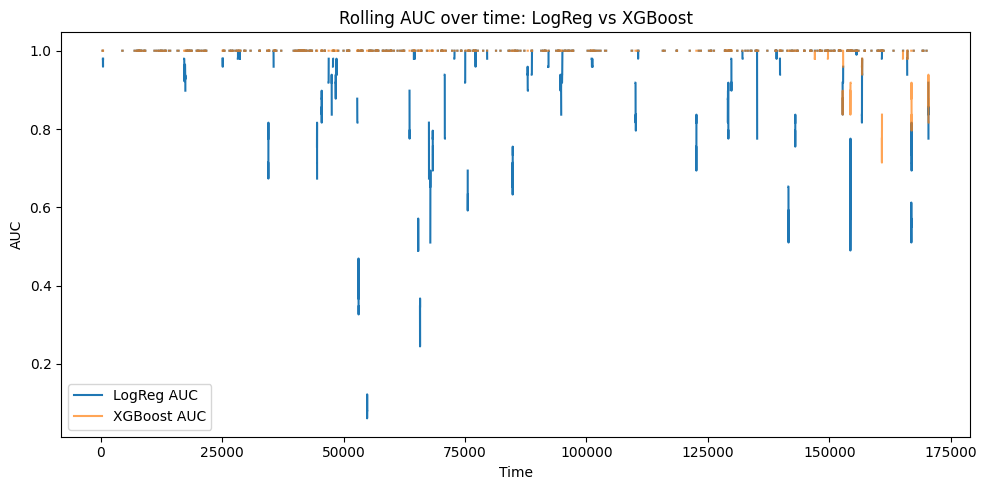

In [57]:
plt.figure(figsize=(10, 5))
plt.plot(metrics_df["end_time_value"], metrics_df["auc"], label="LogReg AUC")
plt.plot(metrics_df_xgb["end_time_value"], metrics_df_xgb["auc"], label="XGBoost AUC", alpha=0.7)
plt.xlabel("Time")
plt.ylabel("AUC")
plt.title("Rolling AUC over time: LogReg vs XGBoost")
plt.legend()
plt.tight_layout()
plt.show()
